# Hai model acceptance — trình bày theo **mốc tăng/giảm giá**

**Yêu cầu gốc của mentor:**

> *"thử tìm cách model xem **khả năng chấp nhận giá của khách tăng hay giảm** knowing **giá đối thủ**
> và cả **thời tiết** nữa, **2 model**"*

**Hai model ở đây là 2 phân tích, phân biệt theo biến điều kiện — không phải 2 thuật toán:**

| | Biến điều kiện | Câu hỏi trả lời |
|---|---|---|
| **MODEL 1** | Giá đối thủ | Mình đổi giá X% so với đối thủ → khả năng chấp nhận đổi bao nhiêu? |
| **MODEL 2** | Thời tiết | Trời mưa → khả năng chấp nhận dịch chuyển bao nhiêu? |

**Khác gì notebook 01:** notebook 01 vẽ đường cong liên tục. Notebook này quy về **các mốc rời rạc**
(±5%, ±10%, ±15%, ±20%, ±25%, ±30%) để đọc nhanh và đối chiếu trực tiếp với số liệu thực tế của team
mentor.

---

## ⚠️ Nhắc lại giới hạn

Dữ liệu **không có nhãn accept/reject** (`booking_or_completion_outcomes_generated = False`, và
placebo test xác nhận generator không mô phỏng phản ứng hành vi với giá). Đây là **mô phỏng dựa trên
giả định elasticity**, không phải model học từ dữ liệu. Mọi kết quả đều kèm dải độ nhạy.

In [1]:
import warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = "#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#666666"
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.titlesize": 11, "axes.labelsize": 9.5,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5, "legend.fontsize": 8.5,
    "savefig.dpi": 150, "savefig.bbox": "tight", "font.size": 9.5,
})
pd.set_option("display.width", 220)
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

P0 = 0.5   # muc chap nhan nen khi gia ngang bang doi thu

def P_accept(ty_le, eps, P0=P0, dich=0.0):
    b = eps / (1 - P0)
    a = np.log(P0 / (1 - P0))
    return 1 / (1 + np.exp(-(a + b * (np.log(ty_le) - np.log1p(dich)))))

# Cac moc doi gia dem phan tich
MOC = [-0.30, -0.25, -0.20, -0.15, -0.10, -0.05, 0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
EPS_M = [-0.3, -0.5, -0.7]           # MARKET-level (ca thi truong cung tang)
EPS_F = [-1.2, -2.0, -3.0]           # FIRM-level  (chi minh tang)
EPS_F_CHINH = -2.0
print("Cau hinh xong.")
print(f"  Moc doi gia : {[f'{m*100:+.0f}%' for m in MOC]}")
print(f"  eps MARKET  : {EPS_M}")
print(f"  eps FIRM    : {EPS_F}  (chinh: {EPS_F_CHINH})")

Cau hinh xong.
  Moc doi gia : ['-30%', '-25%', '-20%', '-15%', '-10%', '-5%', '+0%', '+5%', '+10%', '+15%', '+20%', '+25%', '+30%']
  eps MARKET  : [-0.3, -0.5, -0.7]
  eps FIRM    : [-1.2, -2.0, -3.0]  (chinh: -2.0)


## 1. Hiệu chỉnh tham số bối cảnh từ dữ liệu

In [2]:
cols = ["target_request_id", "gio_vn", "weather_main", "target_shown_price", "target_shown_multiplier"]
d = pd.read_parquet("../../data/hcm_train_ready.parquet", columns=cols)
d = d.drop_duplicates(subset="target_request_id")
d["mua"] = d.weather_main.isin(["Rain", "Drizzle", "Thunderstorm"])
print(f"So chuyen (da khu trung lap 4 lag): {len(d):,}")

gm = d.groupby("mua").target_shown_multiplier.mean()
DICH_MUA = gm[True] / gm[False] - 1
gh = d.groupby("gio_vn").target_shown_multiplier.mean()
DICH_GIO = gh / gh.mean() - 1
GIA_DT = d.target_shown_price.median()

print(f"\nDich chuyen WTP do mua : {DICH_MUA*100:+.2f}%")
print(f"Bien do WTP theo gio   : {(gh.max()/gh.min()-1)*100:.1f}%")
print(f"Gia doi thu median     : {GIA_DT:,.0f} VND")

So chuyen (da khu trung lap 4 lag): 1,724,714

Dich chuyen WTP do mua : +4.61%
Bien do WTP theo gio   : 50.0%
Gia doi thu median     : 114,000 VND


---

# 📊 MODEL 1 — Khả năng chấp nhận theo **GIÁ ĐỐI THỦ**

Phải tách **hai tình huống hoàn toàn khác nhau**, vì chúng cho câu trả lời ngược nhau:

| | Tình huống | Khách có thể làm gì | Elasticity |
|---|---|---|---|
| **1A** | **Cả thị trường** cùng tăng giá | Chỉ *đi* hoặc *không đi* | Market: −0,3 → −0,7 |
| **1B** | **Chỉ mình** tăng, đối thủ giữ nguyên | Có thể **chuyển sang đối thủ** | Firm: −1,2 → −3,0 |

## 1A. Cả thị trường cùng tăng giá

Đây đúng là tình huống thí nghiệm classical algo của mentor.

$$Q_{\text{mới}}/Q_{\text{cũ}} = (1+p)^{\varepsilon}, \qquad
\text{GMV}_{\text{mới}}/\text{GMV}_{\text{cũ}} = (1+p)^{1+\varepsilon}$$

In [3]:
rows = []
for p in [m for m in MOC if m >= 0]:
    r = {"tang_gia": f"{p*100:+.0f}%"}
    for e in EPS_M:
        r[f"SL (ε={e})"] = f"{((1+p)**e - 1)*100:+.1f}%"
        r[f"GMV (ε={e})"] = f"{((1+p)**(1+e) - 1)*100:+.1f}%"
    rows.append(r)
bang_1a = pd.DataFrame(rows).set_index("tang_gia")
print("BANG 1A - CA THI TRUONG cung tang gia  (SL = san luong)")
display(bang_1a)
print("Doc: eps=-0.5, tang gia 20% -> mat 8.7% so cuoc nhung GMV van +9.5%")
print("     Vi |eps| < 1: san luong giam CHAM HON gia tang -> GMV tang.")

BANG 1A - CA THI TRUONG cung tang gia  (SL = san luong)


,SL (ε=-0.3),GMV (ε=-0.3),SL (ε=-0.5),GMV (ε=-0.5),SL (ε=-0.7),GMV (ε=-0.7)
tang_gia,,,,,,
+0%,+0.0%,+0.0%,+0.0%,+0.0%,+0.0%,+0.0%
+5%,-1.5%,+3.5%,-2.4%,+2.5%,-3.4%,+1.5%
+10%,-2.8%,+6.9%,-4.7%,+4.9%,-6.5%,+2.9%
+15%,-4.1%,+10.3%,-6.7%,+7.2%,-9.3%,+4.3%
+20%,-5.3%,+13.6%,-8.7%,+9.5%,-12.0%,+5.6%
+25%,-6.5%,+16.9%,-10.6%,+11.8%,-14.5%,+6.9%
+30%,-7.6%,+20.2%,-12.3%,+14.0%,-16.8%,+8.2%


Doc: eps=-0.5, tang gia 20% -> mat 8.7% so cuoc nhung GMV van +9.5%
     Vi |eps| < 1: san luong giam CHAM HON gia tang -> GMV tang.


### ⭐ Suy ngược elasticity từ bằng chứng GMV của mentor

> *"classical surge pricing algo... chạy thử ra kết quả tốt **tăng cả gần 10% GMV** mấy quận trung tâm"*

Dò trong bảng 1A xem tổ hợp `(mức tăng giá, elasticity)` nào cho GMV ≈ +10%:

In [4]:
print("TO HOP CHO GMV ~ +10%:")
print(f"{'tang gia':>10} {'eps_M':>8} {'GMV':>9}   {'san luong':>11}")
print("-" * 46)
kq = []
for p in np.arange(0.05, 0.51, 0.01):
    for e in np.arange(-0.80, -0.19, 0.01):
        g = (1+p)**(1+e) - 1
        if abs(g - 0.10) < 0.004:
            kq.append((p, e, g, (1+p)**e - 1))
# lay cac moc tron cho de doc
for p_t in [0.10, 0.15, 0.20, 0.25, 0.30, 0.40]:
    gan = [k for k in kq if abs(k[0]-p_t) < 0.005]
    if gan:
        p, e, g, q = gan[0]
        print(f"{p*100:9.0f}% {e:8.2f} {g*100:+8.1f}% {q*100:+10.1f}%")
print()
print("=> GMV +10% tuong thich voi NHIEU to hop. Chi can mentor cho biet")
print("   GIA TANG BAO NHIEU % la chot duoc elasticity, khong can hoi truc tiep.")

TO HOP CHO GMV ~ +10%:
  tang gia    eps_M       GMV     san luong
----------------------------------------------
       15%    -0.34     +9.7%       -4.6%
       20%    -0.49     +9.7%       -8.5%
       25%    -0.58     +9.8%      -12.1%
       30%    -0.65     +9.6%      -15.7%
       40%    -0.72     +9.9%      -21.5%

=> GMV +10% tuong thich voi NHIEU to hop. Chi can mentor cho biet
   GIA TANG BAO NHIEU % la chot duoc elasticity, khong can hoi truc tiep.


## 1B. Chỉ mình tăng giá — đối thủ giữ nguyên

Đây là tình huống dùng cho **quyết định định giá cạnh tranh**.

In [5]:
rows = []
for p in MOC:
    r = {"doi_gia": f"{p*100:+.0f}%"}
    for e in EPS_F:
        P = P_accept(1+p, e)
        r[f"P(accept) ε={e}"] = f"{P*100:.1f}%"
        r[f"Δ ε={e}"] = f"{(P-P0)*100:+.1f}đ"
    rows.append(r)
bang_1b = pd.DataFrame(rows).set_index("doi_gia")
print("BANG 1B - CHI MINH doi gia so voi doi thu   ('d' = diem phan tram)")
display(bang_1b)
print(f"Doc: eps=-2.0, tang gia 10% -> chap nhan tu 50.0% xuong {P_accept(1.10,-2.0)*100:.1f}%")
print(f"     tuc mat {(P0-P_accept(1.10,-2.0))*100:.1f} diem phan tram.")

BANG 1B - CHI MINH doi gia so voi doi thu   ('d' = diem phan tram)


,P(accept) ε=-1.2,Δ ε=-1.2,P(accept) ε=-2.0,Δ ε=-2.0,P(accept) ε=-3.0,Δ ε=-3.0
doi_gia,,,,,,
-30%,70.2%,+20.2đ,80.6%,+30.6đ,89.5%,+39.5đ
-25%,66.6%,+16.6đ,76.0%,+26.0đ,84.9%,+34.9đ
-20%,63.1%,+13.1đ,70.9%,+20.9đ,79.2%,+29.2đ
-15%,59.6%,+9.6đ,65.7%,+15.7đ,72.6%,+22.6đ
-10%,56.3%,+6.3đ,60.4%,+10.4đ,65.3%,+15.3đ
-5%,53.1%,+3.1đ,55.1%,+5.1đ,57.6%,+7.6đ
+0%,50.0%,+0.0đ,50.0%,+0.0đ,50.0%,+0.0đ
+5%,47.1%,-2.9đ,45.1%,-4.9đ,42.7%,-7.3đ
+10%,44.3%,-5.7đ,40.6%,-9.4đ,36.1%,-13.9đ


Doc: eps=-2.0, tang gia 10% -> chap nhan tu 50.0% xuong 40.6%
     tuc mat 9.4 diem phan tram.


In [6]:
# Doanh thu ky vong tuong ung
rows = []
for p in MOC:
    r = {"doi_gia": f"{p*100:+.0f}%"}
    for e in EPS_F:
        R = (1+p) * P_accept(1+p, e)
        R0 = 1.0 * P_accept(1.0, e)
        r[f"ε={e}"] = f"{(R/R0-1)*100:+.1f}%"
    rows.append(r)
bang_1c = pd.DataFrame(rows).set_index("doi_gia")
print("BANG 1C - DOANH THU KY VONG khi chi minh doi gia")
display(bang_1c)

for e in EPS_F:
    Rs = [(1+p) * P_accept(1+p, e) for p in MOC]
    i = int(np.argmax(Rs))
    print(f"  eps={e}: doanh thu cao nhat tai moc {MOC[i]*100:+.0f}%")

BANG 1C - DOANH THU KY VONG khi chi minh doi gia


,ε=-1.2,ε=-2.0,ε=-3.0
doi_gia,,,
-30%,-1.7%,+12.9%,+25.3%
-25%,-0.1%,+13.9%,+27.3%
-20%,+0.9%,+13.5%,+26.8%
-15%,+1.4%,+11.7%,+23.4%
-10%,+1.3%,+8.7%,+17.5%
-5%,+0.8%,+4.7%,+9.5%
+0%,+0.0%,+0.0%,+0.0%
+5%,-1.1%,-5.2%,-10.3%
+10%,-2.5%,-10.7%,-20.6%


  eps=-1.2: doanh thu cao nhat tai moc -15%
  eps=-2.0: doanh thu cao nhat tai moc -25%
  eps=-3.0: doanh thu cao nhat tai moc -25%


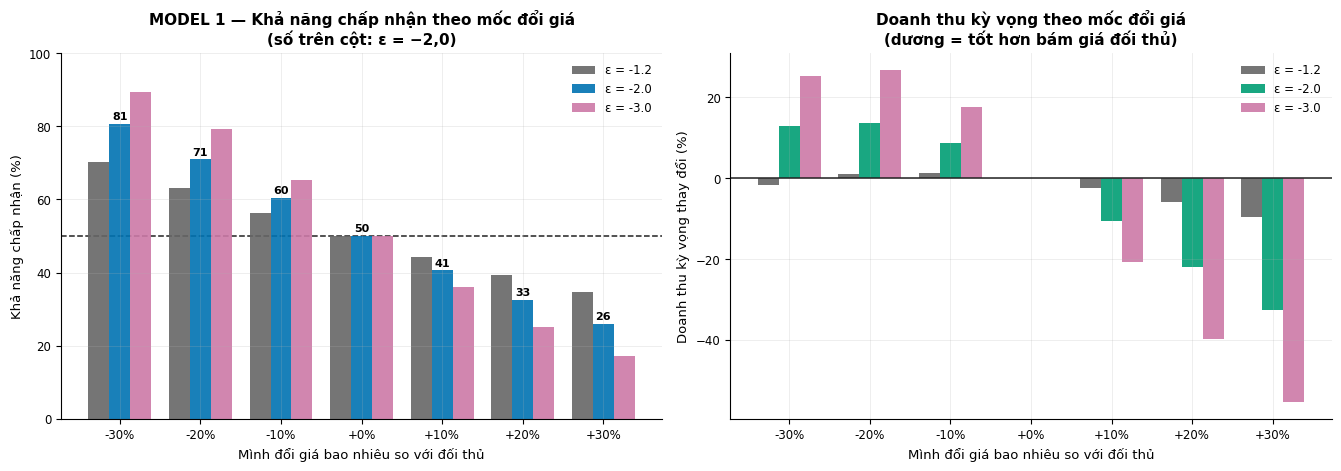

In [7]:
# ===================== HINH A3 =====================
moc_ve = [-0.30, -0.20, -0.10, 0.0, 0.10, 0.20, 0.30]
x = np.arange(len(moc_ve)); w = 0.26

fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.8))

for k, (e, col) in enumerate(zip(EPS_F, [MUT, BLUE, PURPLE])):
    vals = [P_accept(1+p, e)*100 for p in moc_ve]
    b = ax[0].bar(x + (k-1)*w, vals, w, color=col, alpha=0.9, label=f"ε = {e}")
    if e == EPS_F_CHINH:
        for bb, v in zip(b, vals):
            ax[0].text(bb.get_x()+bb.get_width()/2, v+1.2, f"{v:.0f}", ha="center", fontsize=8, fontweight="bold")
ax[0].axhline(P0*100, color=INK, lw=1.1, ls="--", zorder=0)
ax[0].set_xticks(x); ax[0].set_xticklabels([f"{p*100:+.0f}%" for p in moc_ve])
ax[0].set_xlabel("Mình đổi giá bao nhiêu so với đối thủ")
ax[0].set_ylabel("Khả năng chấp nhận (%)")
ax[0].set_title("MODEL 1 — Khả năng chấp nhận theo mốc đổi giá\n(số trên cột: ε = −2,0)", fontweight="bold")
ax[0].legend(frameon=False); ax[0].set_ylim(0, 100)

for k, (e, col) in enumerate(zip(EPS_F, [MUT, GREEN, PURPLE])):
    vals = [((1+p)*P_accept(1+p, e) / (1.0*P_accept(1.0, e)) - 1)*100 for p in moc_ve]
    ax[1].bar(x + (k-1)*w, vals, w, color=col, alpha=0.9, label=f"ε = {e}")
ax[1].axhline(0, color=INK, lw=1.1)
ax[1].set_xticks(x); ax[1].set_xticklabels([f"{p*100:+.0f}%" for p in moc_ve])
ax[1].set_xlabel("Mình đổi giá bao nhiêu so với đối thủ")
ax[1].set_ylabel("Doanh thu kỳ vọng thay đổi (%)")
ax[1].set_title("Doanh thu kỳ vọng theo mốc đổi giá\n(dương = tốt hơn bám giá đối thủ)", fontweight="bold")
ax[1].legend(frameon=False)

plt.tight_layout(); plt.savefig(HINH / "A3_model1_moc_gia.png"); plt.show()

### Kết luận Model 1

> **Chiều:** khả năng chấp nhận **giảm** khi giá mình cao hơn đối thủ, **tăng** khi thấp hơn.
>
> **Nghịch lý biểu kiến — hai câu trả lời ngược nhau, nhưng không mâu thuẫn:**
>
> | Câu hỏi | Elasticity | Trả lời |
> |---|---|---|
> | Cả thị trường có nên tăng giá? | Market (−0,5) | **CÓ** — GMV tăng ✅ khớp bằng chứng mentor |
> | Mình có nên bán đắt hơn đối thủ? | Firm (−2,0) | **KHÔNG** — mất khách vào tay đối thủ |
>
> Lý do: hai tình huống khác nhau về **lựa chọn thay thế** của khách. Cả thị trường tăng giá thì
> khách chỉ có thể bỏ đi; riêng mình tăng thì khách chạy sang đối thủ.

---

# 🌧️ MODEL 2 — Khả năng chấp nhận theo **THỜI TIẾT**

**Cơ chế:** mưa → lựa chọn thay thế (đi bộ, xe buýt, xe máy) kém hấp dẫn → sẵn sàng chi trả tăng →
tại **cùng một mức giá**, khả năng chấp nhận **tăng**.

Mức dịch chuyển WTP **đo từ dữ liệu**, không phải giả định.

In [8]:
rows = []
for p in MOC:
    P_k = P_accept(1+p, EPS_F_CHINH, dich=0.0)
    P_m = P_accept(1+p, EPS_F_CHINH, dich=DICH_MUA)
    rows.append({"doi_gia": f"{p*100:+.0f}%",
                 "khong_mua": f"{P_k*100:.1f}%",
                 "co_mua": f"{P_m*100:.1f}%",
                 "chenh": f"{(P_m-P_k)*100:+.2f}đ"})
bang_2 = pd.DataFrame(rows).set_index("doi_gia")
print(f"BANG 2 - Anh huong THOI TIET tai tung moc gia  (eps = {EPS_F_CHINH})")
display(bang_2)

print("Y nghia thuc te:")
gia_tuong_duong = DICH_MUA * 100
print(f"  Khi mua, co the TANG GIA them ~{gia_tuong_duong:.1f}% ma van giu nguyen ty le chap nhan.")

BANG 2 - Anh huong THOI TIET tai tung moc gia  (eps = -2.0)


,khong_mua,co_mua,chenh
doi_gia,,,
-30%,80.6%,83.3%,+2.66đ
-25%,76.0%,79.1%,+3.14đ
-20%,70.9%,74.5%,+3.57đ
-15%,65.7%,69.6%,+3.94đ
-10%,60.4%,64.6%,+4.22đ
-5%,55.1%,59.5%,+4.41đ
+0%,50.0%,54.5%,+4.49đ
+5%,45.1%,49.6%,+4.49đ
+10%,40.6%,45.0%,+4.41đ


Y nghia thuc te:
  Khi mua, co the TANG GIA them ~4.6% ma van giu nguyen ty le chap nhan.


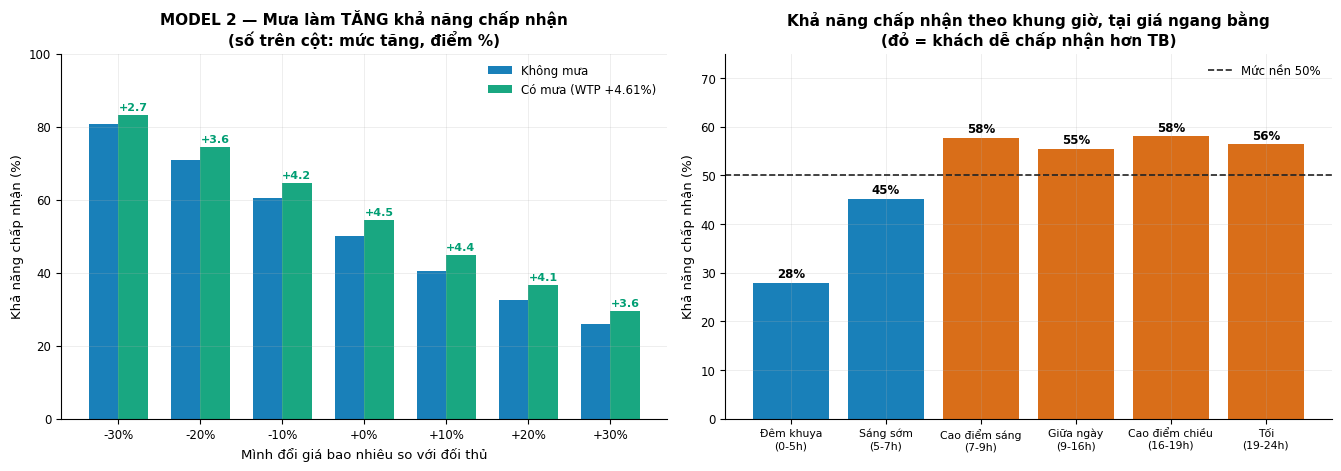

Bien do theo khung gio: 27.9% -> 58.1% = 30.2 diem %
Anh huong cua mua      : 4.49 diem %
-> GIO manh hon MUA gap 6.7 lan


In [9]:
# ===================== HINH A4 =====================
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.8))

x2 = np.arange(len(moc_ve)); w2 = 0.36
v_kho = [P_accept(1+p, EPS_F_CHINH, dich=0.0)*100 for p in moc_ve]
v_mua = [P_accept(1+p, EPS_F_CHINH, dich=DICH_MUA)*100 for p in moc_ve]
b1 = ax[0].bar(x2 - w2/2, v_kho, w2, color=BLUE,  alpha=0.9, label="Không mưa")
b2 = ax[0].bar(x2 + w2/2, v_mua, w2, color=GREEN, alpha=0.9, label=f"Có mưa (WTP {DICH_MUA*100:+.2f}%)")
for bb, v1, v2 in zip(b2, v_kho, v_mua):
    ax[0].text(bb.get_x()+bb.get_width()/2, v2+1.2, f"+{v2-v1:.1f}", ha="center",
               fontsize=8, color=GREEN, fontweight="bold")
ax[0].set_xticks(x2); ax[0].set_xticklabels([f"{p*100:+.0f}%" for p in moc_ve])
ax[0].set_xlabel("Mình đổi giá bao nhiêu so với đối thủ")
ax[0].set_ylabel("Khả năng chấp nhận (%)")
ax[0].set_title("MODEL 2 — Mưa làm TĂNG khả năng chấp nhận\n(số trên cột: mức tăng, điểm %)",
                fontweight="bold")
ax[0].legend(frameon=False); ax[0].set_ylim(0, 100)

# Theo 6 khung gio
def khung(h):
    if h < 5:  return 0
    if h < 7:  return 1
    if h < 9:  return 2
    if h < 16: return 3
    if h < 19: return 4
    return 5
TEN = ["Đêm khuya\n(0-5h)", "Sáng sớm\n(5-7h)", "Cao điểm sáng\n(7-9h)",
       "Giữa ngày\n(9-16h)", "Cao điểm chiều\n(16-19h)", "Tối\n(19-24h)"]
dich_khung = [np.mean([DICH_GIO[h] for h in range(24) if khung(h) == k]) for k in range(6)]
P_khung = [P_accept(1.0, EPS_F_CHINH, dich=dd)*100 for dd in dich_khung]
cols = [RED if v > P0*100 else BLUE for v in P_khung]
bb = ax[1].bar(range(6), P_khung, color=cols, alpha=0.9)
for b_, v in zip(bb, P_khung):
    ax[1].text(b_.get_x()+b_.get_width()/2, v+1.0, f"{v:.0f}%", ha="center", fontsize=8.5, fontweight="bold")
ax[1].axhline(P0*100, color=INK, lw=1.2, ls="--", label="Mức nền 50%")
ax[1].set_xticks(range(6)); ax[1].set_xticklabels(TEN, fontsize=7.8)
ax[1].set_ylabel("Khả năng chấp nhận (%)")
ax[1].set_title("Khả năng chấp nhận theo khung giờ, tại giá ngang bằng\n(đỏ = khách dễ chấp nhận hơn TB)",
                fontweight="bold")
ax[1].legend(frameon=False); ax[1].set_ylim(0, 75)

plt.tight_layout(); plt.savefig(HINH / "A4_model2_moc_thoitiet.png"); plt.show()

print(f"Bien do theo khung gio: {min(P_khung):.1f}% -> {max(P_khung):.1f}% "
      f"= {max(P_khung)-min(P_khung):.1f} diem %")
print(f"Anh huong cua mua      : {(P_accept(1.0,EPS_F_CHINH,dich=DICH_MUA)-P_accept(1.0,EPS_F_CHINH))*100:.2f} diem %")
print(f"-> GIO manh hon MUA gap {(max(P_khung)-min(P_khung))/((P_accept(1.0,EPS_F_CHINH,dich=DICH_MUA)-P_accept(1.0,EPS_F_CHINH))*100):.1f} lan")

### Kết luận Model 2

> **Chiều:** mưa **làm tăng** khả năng chấp nhận. Tương đương: khi mưa có thể **tăng giá ~4,6%** mà
> vẫn giữ nguyên tỷ lệ chấp nhận.
>
> **Nhưng giờ mạnh hơn thời tiết nhiều lần.** Nếu chỉ chọn được một tín hiệu để điều chỉnh giá,
> **giờ trong ngày** quan trọng hơn hẳn **thời tiết**.
>
> Nhất quán với báo cáo tuần 2: η(giờ → hệ số nhân) = 0,702 so với η(thời tiết) = 0,153.

---

## 3. Bảng tra cứu tổng hợp — **mốc giá × khung giờ**

Gộp Model 1 và Model 2 thành một bảng dùng được trực tiếp.

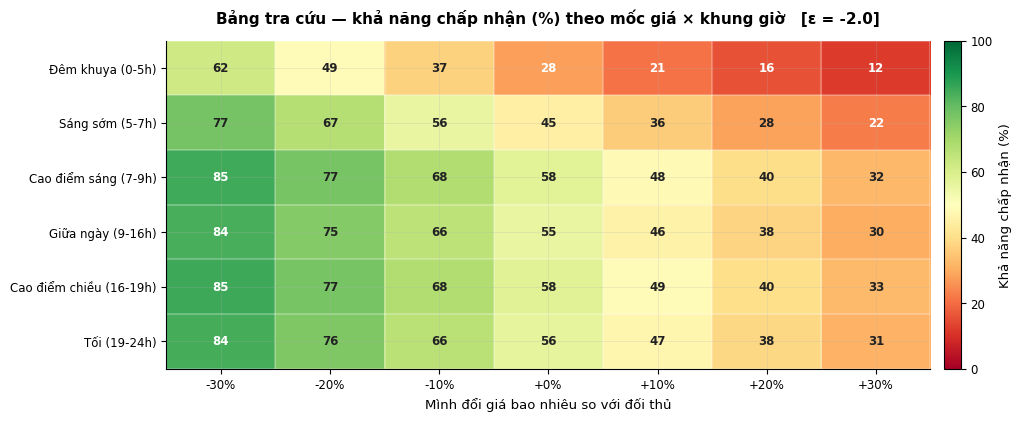

Bang tra cuu dang so:


,-30%,-20%,-10%,+0%,+10%,+20%,+30%
Đêm khuya (0-5h),61.8,48.6,37.2,27.9,20.9,15.8,12.0
Sáng sớm (5-7h),77.4,66.8,55.7,45.2,36.0,28.5,22.4
Cao điểm sáng (7-9h),85.1,77.0,67.6,57.8,48.3,39.7,32.4
Giữa ngày (9-16h),83.8,75.3,65.5,55.5,46.0,37.5,30.4
Cao điểm chiều (16-19h),85.2,77.2,67.9,58.1,48.6,40.1,32.7
Tối (19-24h),84.4,76.0,66.4,56.4,46.9,38.4,31.2


In [10]:
M = np.zeros((6, len(moc_ve)))
for i, dd in enumerate(dich_khung):
    for j, p in enumerate(moc_ve):
        M[i, j] = P_accept(1+p, EPS_F_CHINH, dich=dd) * 100

fig, ax = plt.subplots(figsize=(11, 4.3))
im = ax.imshow(M, cmap="RdYlGn", aspect="auto", vmin=0, vmax=100)
ax.set_xticks(range(len(moc_ve))); ax.set_xticklabels([f"{p*100:+.0f}%" for p in moc_ve])
ax.set_yticks(range(6)); ax.set_yticklabels([t.replace("\n", " ") for t in TEN], fontsize=8.5)
ax.set_xlabel("Mình đổi giá bao nhiêu so với đối thủ")
ax.set_title(f"Bảng tra cứu — khả năng chấp nhận (%) theo mốc giá × khung giờ   [ε = {EPS_F_CHINH}]",
             fontweight="bold", pad=12)
for i in range(6):
    for j in range(len(moc_ve)):
        ax.text(j, i, f"{M[i,j]:.0f}", ha="center", va="center", fontsize=8.5,
                color="white" if (M[i,j] < 28 or M[i,j] > 78) else INK, fontweight="bold")
ax.set_xticks(np.arange(-.5, len(moc_ve), 1), minor=True)
ax.set_yticks(np.arange(-.5, 6, 1), minor=True)
ax.grid(which="minor", color="white", lw=1.5); ax.tick_params(which="minor", length=0)
plt.colorbar(im, ax=ax, label="Khả năng chấp nhận (%)", pad=0.015)
plt.tight_layout(); plt.savefig(HINH / "A5_bang_tracuu.png"); plt.show()

print("Bang tra cuu dang so:")
display(pd.DataFrame(M.round(1),
                     index=[t.replace("\n"," ") for t in TEN],
                     columns=[f"{p*100:+.0f}%" for p in moc_ve]))

## 4. Kiểm tra tính vững — kết luận có đổi khi thay giả định không?

In [11]:
rows = []
for e in EPS_F:
    Rs = [(1+p) * P_accept(1+p, e) for p in MOC]
    i = int(np.argmax(Rs))
    P_k = P_accept(1.0, e, dich=0.0); P_m = P_accept(1.0, e, dich=DICH_MUA)
    Pg = [P_accept(1.0, e, dich=dd) for dd in dich_khung]
    rows.append({
        "elasticity": e,
        "moc_gia_toi_uu": f"{MOC[i]*100:+.0f}%",
        "toi_uu_am?": "CO" if MOC[i] < 0 else "KHONG",
        "mua_tang_(diem%)": round((P_m-P_k)*100, 2),
        "bien_do_gio_(diem%)": round((max(Pg)-min(Pg))*100, 2),
        "gio>mua?": "CO" if (max(Pg)-min(Pg)) > (P_m-P_k) else "KHONG",
    })
bang_vung = pd.DataFrame(rows)
display(bang_vung)
print("TINH VUNG:")
print(f"  1. Moc gia toi uu la GIAM gia : {bang_vung['toi_uu_am?'].eq('CO').sum()}/{len(bang_vung)}")
print(f"  2. Mua LAM TANG chap nhan     : {(bang_vung['mua_tang_(diem%)'] > 0).sum()}/{len(bang_vung)}")
print(f"  3. Gio manh hon thoi tiet     : {bang_vung['gio>mua?'].eq('CO').sum()}/{len(bang_vung)}")

,elasticity,moc_gia_toi_uu,toi_uu_am?,mua_tang_(diem%),bien_do_gio_(diem%),gio>mua?
0,-1.2,-15%,CO,2.70,18.72,CO
1,-2.0,-25%,CO,4.49,30.15,CO
2,-3.0,-25%,CO,6.72,42.56,CO


TINH VUNG:
  1. Moc gia toi uu la GIAM gia : 3/3
  2. Mua LAM TANG chap nhan     : 3/3
  3. Gio manh hon thoi tiet     : 3/3


## 5. Tổng kết

### Trả lời trực tiếp yêu cầu mentor

| Model | Câu hỏi | Trả lời |
|---|---|---|
| **1** | Biết **giá đối thủ** → chấp nhận tăng hay giảm? | **GIẢM** khi giá mình cao hơn. Ở ε=−2,0: tăng 10% → chấp nhận 50% → 40,6% (mất 9,4 điểm %) |
| **2** | Biết **thời tiết** → chấp nhận tăng hay giảm? | **TĂNG** khi mưa (+4,5 điểm %). Tương đương tăng giá được 4,6% mà không mất khách |

### Ba kết luận vững trên toàn dải elasticity

1. Mốc giá tối ưu là **giảm giá** so với đối thủ (cạnh tranh trực tiếp rất co giãn)
2. Mưa **làm tăng** khả năng chấp nhận
3. **Giờ trong ngày** tác động mạnh hơn **thời tiết** nhiều lần

### Điểm cần trao đổi với mentor

Thay vì hỏi elasticity (khó trả lời), chỉ cần hỏi **mức tăng giá trong thí nghiệm classical algo**:

> *"Bọn em lập bảng GMV theo từng mức tăng giá. GMV +10% khớp với giá tăng ~15% (ε≈−0,3) hoặc
> ~20–25% (ε≈−0,5). Anh xem mức nào gần thực tế nhất ạ?"*

Và 2 câu về dữ liệu outcome:

> *"Hệ thống có log lần **hiển thị giá mà khách không đặt** không, hay chỉ log cuốc đã đặt?"*
>
> *"Trong outcome có tách được **`no_driver_found`** khỏi **khách chủ động không đặt** không ạ?"*